<a href="https://colab.research.google.com/github/Gaby2318/Aplicacion-del-metodo/blob/main/Aplicaci%C3%B3n_del_metodo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importamos librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

1. Crear datos simulados para la aplicacion de admision de estudiantes a la universidad

In [2]:
print("="*50)
print("PASO 1: Creando dataset de admisión universitaria")
print("="*50)

# Datos de 20 estudiantes
datos = {
    'promedio': [55, 58, 60, 62, 65, 67, 68, 70, 72, 74,
                  76, 78, 80, 82, 85, 87, 89, 90, 92, 95],
    'examen': [50, 52, 55, 58, 60, 63, 65, 68, 70, 73,
               75, 78, 80, 82, 85, 87, 88, 90, 92, 94],
    'admitido': [0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
                 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(datos)
print(df.head(10))
print(f"\nTotal de estudiantes: {len(df)}")
print(f"Admitidos: {df['admitido'].sum()}")
print(f"No admitidos: {len(df) - df['admitido'].sum()}")

PASO 1: Creando dataset de admisión universitaria
   promedio  examen  admitido
0        55      50         0
1        58      52         0
2        60      55         0
3        62      58         0
4        65      60         0
5        67      63         0
6        68      65         0
7        70      68         1
8        72      70         1
9        74      73         1

Total de estudiantes: 20
Admitidos: 13
No admitidos: 7


2. NORMALIZAR DATOS

In [3]:
print("\n" + "="*50)
print("PASO 2: Normalizando datos (para mejor convergencia)")
print("="*50)

def normalizar(x):
    return (x - np.mean(x)) / np.std(x)

# Normalizamos las variables predictoras
df['promedio_norm'] = normalizar(df['promedio'])
df['examen_norm'] = normalizar(df['examen'])

print("Estadísticas después de normalizar:")
print(f"Promedio norm - media: {df['promedio_norm'].mean():.2f}, std: {df['promedio_norm'].std():.2f}")
print(f"Examen norm - media: {df['examen_norm'].mean():.2f}, std: {df['examen_norm'].std():.2f}")



PASO 2: Normalizando datos (para mejor convergencia)
Estadísticas después de normalizar:
Promedio norm - media: -0.00, std: 1.03
Examen norm - media: 0.00, std: 1.03


3. FUNCIONES DEL MODELO

In [4]:
print("\n" + "="*50)
print("PASO 3: Definiendo funciones matemáticas")
print("="*50)

def sigmoide(z):
    """Función sigmoide: convierte cualquier número en probabilidad entre 0 y 1"""
    return 1 / (1 + np.exp(-z))

def predecir(X, betas):
    """Calcula la probabilidad de pertenecer a la clase 1"""
    z = np.dot(X, betas)
    return sigmoide(z)

def costo(betas, X, y):
    """Función de costo logarítmica (log-loss)"""
    m = len(y)
    h = predecir(X, betas)
    # Evitamos log(0) agregando un epsilon muy pequeño
    epsilon = 1e-5
    costo = (-1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    return costo

def gradiente_descendente(X, y, alpha=0.1, iteraciones=1000):
    """
    Entrena el modelo usando gradiente descendente
    alpha: tasa de aprendizaje
    iteraciones: número de épocas de entrenamiento
    """
    m, n = X.shape
    betas = np.zeros(n)  # Inicializar betas en cero
    historial_costo = []

    for i in range(iteraciones):
        h = predecir(X, betas)
        gradiente = (1/m) * np.dot(X.T, (h - y))
        betas = betas - alpha * gradiente
        historial_costo.append(costo(betas, X, y))

        # Mostrar progreso cada 100 iteraciones
        if i % 100 == 0:
            print(f"Iteración {i}, Costo: {historial_costo[-1]:.4f}")

    return betas, historial_costo


PASO 3: Definiendo funciones matemáticas


4. ENTRENAR EL MODELO

In [5]:
print("\n" + "="*50)
print("PASO 4: Entrenando el modelo")
print("="*50)

# Preparar matrices X (agregamos columna de 1s para el intercepto β₀)
X = np.column_stack([np.ones(len(df)), df['promedio_norm'].values, df['examen_norm'].values])
y = df['admitido'].values

print(f"Dimensión de X: {X.shape}")
print(f"Dimensión de y: {y.shape}")

# Entrenar
betas_optimos, historial = gradiente_descendente(X, y, alpha=0.3, iteraciones=1000)

print(f"\nBetas encontrados:")
print(f"β₀ (intercepto): {betas_optimos[0]:.4f}")
print(f"β₁ (promedio): {betas_optimos[1]:.4f}")
print(f"β₂ (examen): {betas_optimos[2]:.4f}")


PASO 4: Entrenando el modelo
Dimensión de X: (20, 3)
Dimensión de y: (20,)
Iteración 0, Costo: 0.5992
Iteración 100, Costo: 0.1299
Iteración 200, Costo: 0.1003
Iteración 300, Costo: 0.0861
Iteración 400, Costo: 0.0771
Iteración 500, Costo: 0.0707
Iteración 600, Costo: 0.0657
Iteración 700, Costo: 0.0618
Iteración 800, Costo: 0.0585
Iteración 900, Costo: 0.0557

Betas encontrados:
β₀ (intercepto): 4.0478
β₁ (promedio): 3.6710
β₂ (examen): 4.6379


5. EVALUAR EL MODELO

In [6]:
print("\n" + "="*50)
print("PASO 5: Evaluando predicciones")
print("="*50)

# Calcular probabilidades para todos los estudiantes
probabilidades = predecir(X, betas_optimos)
predicciones = (probabilidades >= 0.5).astype(int)

# Calcular precisión
precision = np.mean(predicciones == y) * 100
print(f"Precisión del modelo: {precision:.2f}%")

# Tabla comparativa
df_resultados = df[['promedio', 'examen', 'admitido']].copy()
df_resultados['probabilidad'] = probabilidades
df_resultados['prediccion'] = predicciones
df_resultados['correcto'] = df_resultados['admitido'] == df_resultados['prediccion']

print("\nResultados (primeros 10 estudiantes):")
print(df_resultados.head(10))


PASO 5: Evaluando predicciones
Precisión del modelo: 100.00%

Resultados (primeros 10 estudiantes):
   promedio  examen  admitido  probabilidad  prediccion  correcto
0        55      50         0      0.000037           0      True
1        58      52         0      0.000188           0      True
2        60      55         0      0.000973           0      True
3        62      58         0      0.005031           0      True
4        65      60         0      0.024868           0      True
5        67      63         0      0.116924           0      True
6        68      65         0      0.263505           0      True
7        70      68         1      0.650055           1      True
8        72      70         1      0.872738           1      True
9        74      73         1      0.972682           1      True


6. PREDECIR NUEVO ESTUDIANTE

In [7]:
print("\n" + "="*50)
print("PASO 6: Predicción para un nuevo estudiante")
print("="*50)

def predecir_nuevo_estudiante(promedio, examen, betas, df_referencia):
    """Predice probabilidad de admisión para un nuevo estudiante"""
    # Normalizar usando la media y std del dataset original
    prom_norm = (promedio - df_referencia['promedio'].mean()) / df_referencia['promedio'].std()
    exam_norm = (examen - df_referencia['examen'].mean()) / df_referencia['examen'].std()

    # Calcular probabilidad
    z = betas[0] + betas[1]*prom_norm + betas[2]*exam_norm
    prob = sigmoide(z)

    return prob

# Probar 3 nuevos estudiantes
nuevos = [
    (68, 65, "Estudiante A"),
    (75, 78, "Estudiante B"),
    (85, 88, "Estudiante C")
]

print("\nPredicciones para nuevos estudiantes:")
print("-" * 50)
for prom, exam, nombre in nuevos:
    prob = predecir_nuevo_estudiante(prom, exam, betas_optimos, df)
    decision = "ADMITIDO" if prob >= 0.5 else "RECHAZADO"
    print(f"{nombre}: Promedio={prom}, Examen={exam} → Probabilidad={prob:.3f} ({decision})")



PASO 6: Predicción para un nuevo estudiante

Predicciones para nuevos estudiantes:
--------------------------------------------------
Estudiante A: Promedio=68, Examen=65 → Probabilidad=0.289 (RECHAZADO)
Estudiante B: Promedio=75, Examen=78 → Probabilidad=0.996 (ADMITIDO)
Estudiante C: Promedio=85, Examen=88 → Probabilidad=1.000 (ADMITIDO)


7. GRAFICAR RESULTADOS


PASO 7: Generando gráficas


/tmp/ipykernel_1351/938906843.py:37: UserWarning: The following kwargs were not used by contour: 'label'
  contour = ax2.contour(P, E, Z_grid, levels=[0.5], colors='blue', linewidths=2, label='Frontera de decisión')


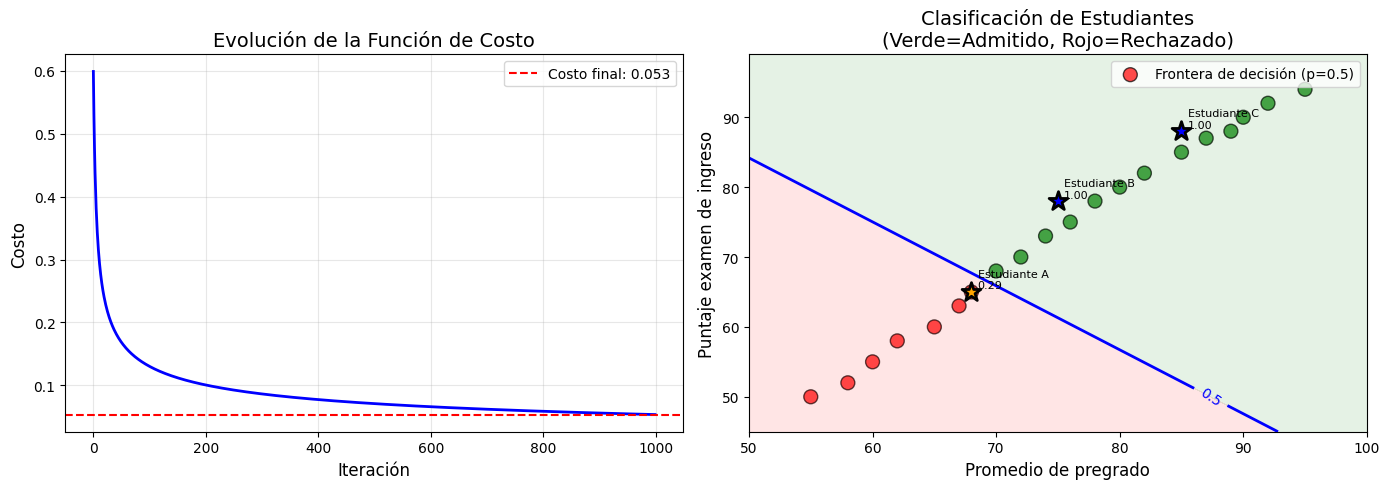

In [8]:
print("\n" + "="*50)
print("PASO 7: Generando gráficas")
print("="*50)

# Figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Evolución del costo durante el entrenamiento
ax1.plot(historial, 'b-', linewidth=2)
ax1.set_xlabel('Iteración', fontsize=12)
ax1.set_ylabel('Costo', fontsize=12)
ax1.set_title('Evolución de la Función de Costo', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=historial[-1], color='r', linestyle='--', label=f'Costo final: {historial[-1]:.3f}')
ax1.legend()

# Gráfico 2: Datos y frontera de decisión
# Colorear puntos según su clase real
colores = ['red' if y_i == 0 else 'green' for y_i in y]
ax2.scatter(df['promedio'], df['examen'], c=colores, s=100, alpha=0.7, edgecolors='black')

# Crear malla para dibujar frontera de decisión
promedios_grid = np.linspace(df['promedio'].min() - 5, df['promedio'].max() + 5, 100)
examenes_grid = np.linspace(df['examen'].min() - 5, df['examen'].max() + 5, 100)
P, E = np.meshgrid(promedios_grid, examenes_grid)

# Calcular probabilidad en cada punto de la malla
Z_grid = np.zeros(P.shape)
for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        prom_norm = (P[i,j] - df['promedio'].mean()) / df['promedio'].std()
        exam_norm = (E[i,j] - df['examen'].mean()) / df['examen'].std()
        z = betas_optimos[0] + betas_optimos[1]*prom_norm + betas_optimos[2]*exam_norm
        Z_grid[i,j] = sigmoide(z)

# Dibujar frontera de decisión (probabilidad = 0.5)
contour = ax2.contour(P, E, Z_grid, levels=[0.5], colors='blue', linewidths=2, label='Frontera de decisión')
ax2.clabel(contour, inline=True, fontsize=10)

# Rellenar regiones
ax2.contourf(P, E, Z_grid, levels=[0, 0.5, 1], alpha=0.1, colors=['red', 'green'])

ax2.set_xlabel('Promedio de pregrado', fontsize=12)
ax2.set_ylabel('Puntaje examen de ingreso', fontsize=12)
ax2.set_title('Clasificación de Estudiantes\n(Verde=Admitido, Rojo=Rechazado)', fontsize=14)
ax2.legend(['Frontera de decisión (p=0.5)'])

# Añadir algunos puntos nuevos destacados
for prom, exam, nombre in nuevos:
    prob = predecir_nuevo_estudiante(prom, exam, betas_optimos, df)
    color = 'blue' if prob >= 0.5 else 'orange'
    ax2.scatter(prom, exam, c=color, s=200, marker='*', edgecolors='black',
                linewidth=2, label=f'{nombre}' if prob >= 0.5 else None)
    ax2.annotate(f'{nombre}\n{prob:.2f}', (prom+0.5, exam+0.5), fontsize=8)

plt.tight_layout()
plt.savefig('regresion_logistica_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

8. RESUMEN FINAL

In [9]:
print("\n" + "="*50)
print("RESUMEN FINAL DEL MODELO")
print("="*50)

print(f"""
Modelo de Regresión Logística - Admisión Universitaria

Ecuación del modelo:
z = {betas_optimos[0]:.4f} + {betas_optimos[1]:.4f}·(promedio_norm) + {betas_optimos[2]:.4f}·(examen_norm)

Interpretación:
- β₁ (coeficiente de promedio) = {betas_optimos[1]:.4f}
  * Es POSITIVO → mayores promedios aumentan probabilidad de admisión

- β₂ (coeficiente de examen) = {betas_optimos[2]:.4f}
  * Es POSITIVO → mejores exámenes aumentan probabilidad de admisión

Métricas de desempeño:
- Precisión: {precision:.2f}%
- Costo final: {historial[-1]:.4f}
- Iteraciones realizadas: {len(historial)}

¿Cómo interpretar la probabilidad?
- Si p ≥ 0.5 → Se predice ADMITIDO
- Si p < 0.5 → Se predice RECHAZADO
""")

print("="*50)
print("FIN DEL ANÁLISIS")
print("="*50)


RESUMEN FINAL DEL MODELO

Modelo de Regresión Logística - Admisión Universitaria

Ecuación del modelo:
z = 4.0478 + 3.6710·(promedio_norm) + 4.6379·(examen_norm)

Interpretación:
- β₁ (coeficiente de promedio) = 3.6710
  * Es POSITIVO → mayores promedios aumentan probabilidad de admisión

- β₂ (coeficiente de examen) = 4.6379
  * Es POSITIVO → mejores exámenes aumentan probabilidad de admisión

Métricas de desempeño:
- Precisión: 100.00%
- Costo final: 0.0533
- Iteraciones realizadas: 1000

¿Cómo interpretar la probabilidad?
- Si p ≥ 0.5 → Se predice ADMITIDO
- Si p < 0.5 → Se predice RECHAZADO

FIN DEL ANÁLISIS
